# Python → C++ inference migration — benchmark comparison

**Project history / collaborator-facing** (not paper-quality). Documents the latency, throughput,
per-stage and energy impact of porting the FPGA inference pipeline from Python to C++.

- **Data**: `cpp_migration_data/<model>/{py,cpp}_{compress,full}_{s0,s1}.json` (next to this notebook,
  committed alongside it). Python from `benchmark_fpga.py`, C++ from `benchmark_hardware`.
- **S0** = sequential (single DPU core), **S1** = channel-parallel (real/imag on 2 cores).
- All runs: warmup 5, iters 50, `--power`, on ZCU102, model λ=1000 seed 0.
- **Caveat**: Python repeats the first patch each iter; C++ cycles a 20-patch subset. Latency-per-patch
  is comparable; entropy-stage timing may differ slightly (bitstream length is data-dependent).

The headline: the C++ win is concentrated in **entropy coding** (C++ rANS vs Python) — the DPU stages
are the same hardware and barely change. So DPU-heavy residual models benefit less in relative terms.

## §0 Setup & loader

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

ROOT_DIR = Path("..").resolve()
DATA_DIR = ROOT_DIR / "notebooks" / "cpp_migration_data"

# PDF figures land here — download this folder to your local machine.
PLOTS_DIR = ROOT_DIR / "results" / "plots" / "cpp_migration"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    plt.savefig(PLOTS_DIR / f"{name}.pdf", bbox_inches="tight")


C = json.load(open(ROOT_DIR / "notebooks" / "plots_colors.json"))
ARCH_CLR = C["architectures"]
STAGE_CLR = C["cpp_stages"]
ARCH_LABEL = {"FP": "FP", "SHyp": "SH", "ResFP": "ResFP", "ResSHyp": "ResSH"}
ARCH_ORDER = ["FP", "SHyp", "ResFP", "ResSHyp"]
FIG_DPI = 120

# C++ stage -> list of Python latency_breakdown keys to sum (from compare_benchmark_s0.py).
# FP family has no h_a/h_s/GC; SHyp family is the full hyperprior path.
CPP_TO_PY = {
    ("FP", "compress"): {
        "normalize": ["preprocess"],
        "g_a": ["dpu_g_a"],
        "eb_compress": ["cpu_eb_compress"],
    },
    ("FP", "full"): {
        "normalize": ["preprocess"],
        "g_a": ["dpu_g_a"],
        "eb_compress": ["cpu_eb_compress"],
        "eb_decompress": ["cpu_eb_decompress"],
        "g_s": ["dpu_g_s"],
        "denorm": ["postprocess"],
    },
    ("SHyp", "compress"): {
        "normalize": ["preprocess"],
        "g_a": ["dpu_g_a", "cpu_concat_abs"],
        "h_a": ["dpu_h_a"],
        "eb_compress": ["cpu_eb_compress"],
        "eb_decompress": ["cpu_eb_decompress"],
        "h_s": ["dpu_h_s"],
        "gc_compress": ["cpu_gc_compress"],
    },
    ("SHyp", "full"): {
        "normalize": ["preprocess"],
        "g_a": ["dpu_g_a", "cpu_concat_abs"],
        "h_a": ["dpu_h_a"],
        "eb_compress": ["cpu_eb_compress"],
        "eb_decompress": ["cpu_eb_decompress"],
        "h_s": ["dpu_h_s"],
        "gc_compress": ["cpu_gc_compress"],
        "gc_decompress": ["cpu_gc_decompress"],
        "g_s": ["cpu_split_y_hat", "dpu_g_s"],
        "denorm": ["postprocess"],
    },
}
CPP_ORDER = {
    ("FP", "compress"): ["normalize", "g_a", "eb_compress"],
    ("FP", "full"): ["normalize", "g_a", "eb_compress", "eb_decompress", "g_s", "denorm"],
    ("SHyp", "compress"): [
        "normalize",
        "g_a",
        "h_a",
        "eb_compress",
        "eb_decompress",
        "h_s",
        "gc_compress",
    ],
    ("SHyp", "full"): [
        "normalize",
        "g_a",
        "h_a",
        "eb_compress",
        "eb_decompress",
        "h_s",
        "gc_compress",
        "gc_decompress",
        "g_s",
        "denorm",
    ],
}
# Canonical stage order for legends (superset)
STAGE_LEGEND_ORDER = CPP_ORDER[("SHyp", "full")]


def family(arch):
    """FP/ResFP share one pipeline shape; SHyp/ResSHyp share the hyperprior shape."""
    return "FP" if arch in ("FP", "ResFP") else "SHyp"


def load_migration():
    rows = []
    for mdir in sorted(DATA_DIR.iterdir()):
        if not mdir.is_dir():
            continue
        model = mdir.name
        arch = model.split("-", 1)[0]
        fam = family(arch)
        for scenario in ("compress", "full"):
            for cfg in ("s0", "s1"):
                cppf, pyf = mdir / f"cpp_{scenario}_{cfg}.json", mdir / f"py_{scenario}_{cfg}.json"
                if not (cppf.exists() and pyf.exists()):
                    continue
                cpp, py = json.load(open(cppf)), json.load(open(pyf))
                order = CPP_ORDER[(fam, scenario)]
                cmap = CPP_TO_PY[(fam, scenario)]
                cpp_stage_ms = {st: cpp["stages"].get(st, {}).get("mean_ms", 0.0) for st in order}
                py_stage_ms = {
                    st: sum(
                        py["latency_breakdown"].get(p, {}).get("mean_s", 0.0) * 1e3
                        for p in (cmap.get(st) or [])
                    )
                    for st in order
                }
                rows.append(
                    {
                        "model": model,
                        "arch": arch,
                        "scenario": scenario,
                        "config": cfg,
                        "cpp_total_ms": cpp["total_latency_mean_ms"],
                        "py_total_ms": py["latency_total_mean_ms"],
                        "cpp_fps": cpp["throughput_fps"],
                        "py_fps": py["throughput_fps"],
                        "cpp_mpsoc_w": cpp.get("power", {})
                        .get("active", {})
                        .get("groups", {})
                        .get("MPSoC", np.nan),
                        "py_mpsoc_w": py.get("power", {})
                        .get("groups_avg_w", {})
                        .get("MPSoC", np.nan),
                        "cpp_order": order,
                        "cpp_stage_ms": cpp_stage_ms,
                        "py_stage_ms": py_stage_ms,
                    }
                )
    df = pd.DataFrame(rows)
    df["cpp_energy_mj"] = df["cpp_mpsoc_w"] * df["cpp_total_ms"]
    df["py_energy_mj"] = df["py_mpsoc_w"] * df["py_total_ms"]
    return df


mig_df = load_migration()


def _archs_present(sub):
    return [a for a in ARCH_ORDER if a in sub["arch"].values]


# Headline table
_disp = mig_df.assign(speedup=(mig_df["py_total_ms"] / mig_df["cpp_total_ms"]).round(2))
print(
    _disp[
        [
            "model",
            "scenario",
            "config",
            "py_total_ms",
            "cpp_total_ms",
            "speedup",
            "py_fps",
            "cpp_fps",
        ]
    ].to_string(index=False)
)

                   model scenario config  py_total_ms  cpp_total_ms  speedup    py_fps   cpp_fps
     FP-relu_s0_L1000_pt compress     s0    61.321983     26.136538     2.35 16.288538 37.891477
     FP-relu_s0_L1000_pt compress     s1    56.726490     21.957323     2.58 17.605398 44.994309
     FP-relu_s0_L1000_pt     full     s0   144.696139     51.294289     2.82  6.906746 19.376593
     FP-relu_s0_L1000_pt     full     s1   136.076358     43.169351     3.15  7.344411 23.011783
  ResFP-relu_s0_L1000_pt compress     s0   124.057018     89.286172     1.39  8.056176 11.163017
  ResFP-relu_s0_L1000_pt compress     s1    88.275964     53.298457     1.66 11.318557 18.662415
  ResFP-relu_s0_L1000_pt     full     s0   270.437267    176.659016     1.53  3.696484  5.650853
  ResFP-relu_s0_L1000_pt     full     s1   200.083553    106.606090     1.88  4.995768  9.352924
ResSHyp-relu_s0_L1000_pt compress     s0   202.143714     96.445267     2.10  4.943833 10.338625
ResSHyp-relu_s0_L1000_pt compr

## §1 Latency & throughput

Total latency/patch and throughput, Python vs C++. One x-group per `(arch, config)` (e.g. `FP / S0`,
`FP / S1`), two bars each: **Python solid, C++ hatched**, colored by architecture. The **× factor
above each C++ bar** is the improvement (latency: Python/C++; throughput: C++/Python). PDF saved to
`results/plots/cpp_migration/`.

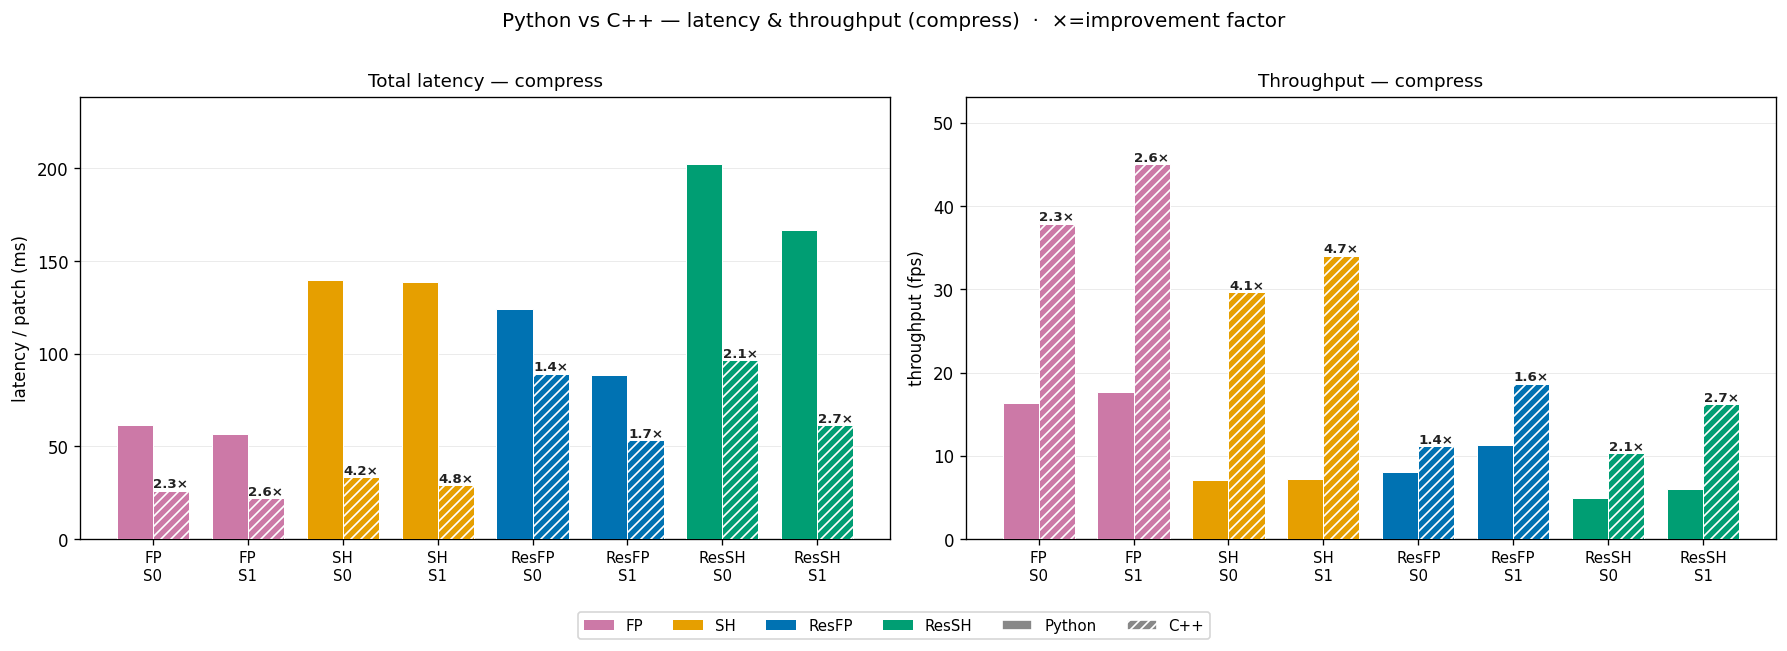

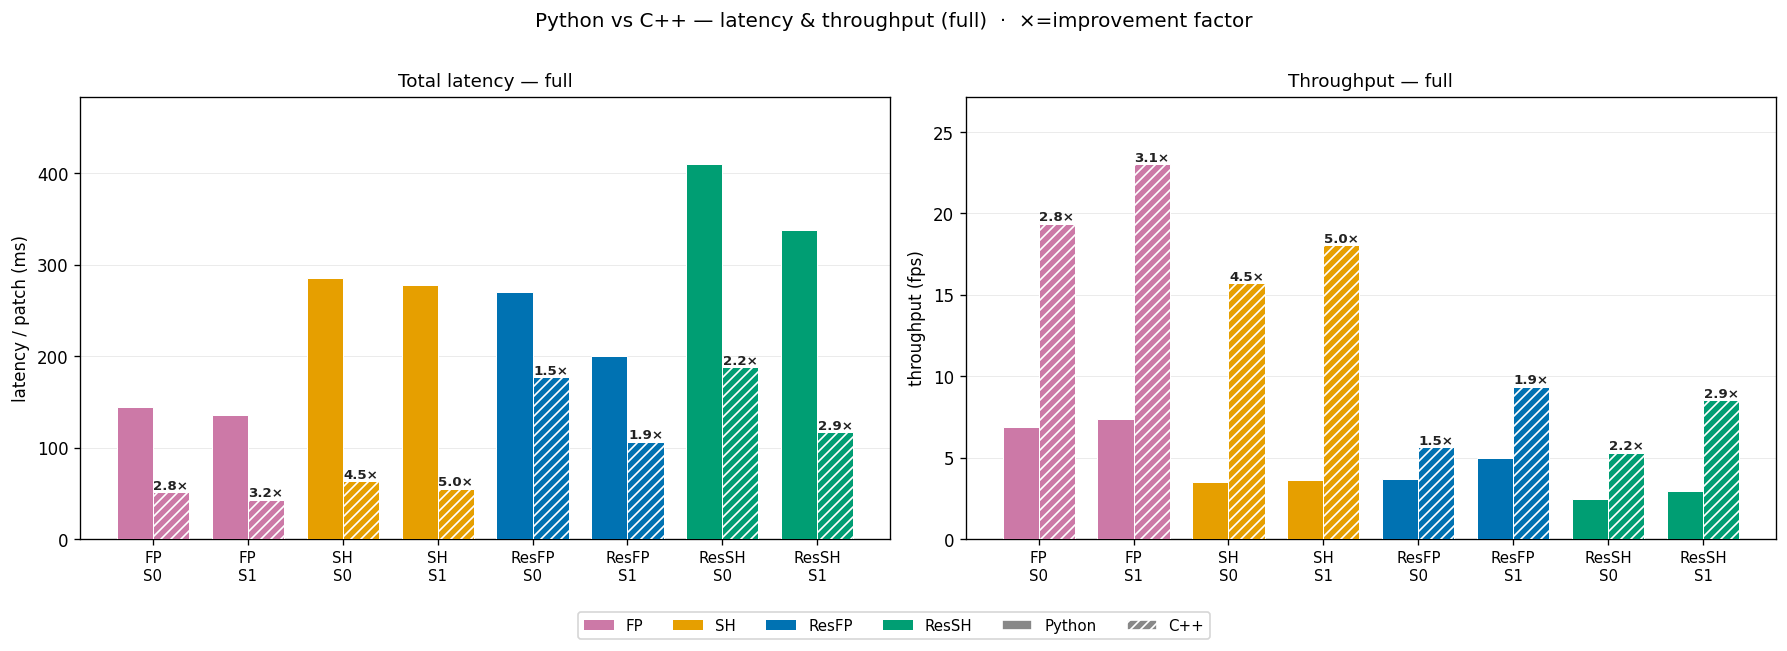

In [6]:
def plot_latency_throughput(scenario="compress"):
    """Latency + throughput, Python vs C++. One x-group per (arch, config); the
    improvement factor (×) is printed above each C++ bar. scenario: 'compress'|'full'."""
    sub = mig_df[mig_df["scenario"] == scenario]
    archs = _archs_present(sub)
    groups = [(a, cfg) for a in archs for cfg in ("s0", "s1")]
    x = np.arange(len(groups))
    w = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), dpi=FIG_DPI)
    for ax, metric, ylab, title, better in [
        (axes[0], "total_ms", "latency / patch (ms)", f"Total latency — {scenario}", "lower"),
        (axes[1], "fps", "throughput (fps)", f"Throughput — {scenario}", "higher"),
    ]:
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linewidth=0.4, alpha=0.35, color="#aaa")
        ymax = 0
        for gi, (arch, cfg) in enumerate(groups):
            r = sub[(sub["arch"] == arch) & (sub["config"] == cfg)]
            if r.empty:
                continue
            r = r.iloc[0]
            clr = ARCH_CLR.get(arch, "#888")
            pyv, cppv = r[f"py_{metric}"], r[f"cpp_{metric}"]
            ymax = max(ymax, pyv, cppv)
            ax.bar(
                x[gi] - w / 2, pyv, width=w, color=clr, edgecolor="white", linewidth=0.6, zorder=3
            )
            ax.bar(
                x[gi] + w / 2,
                cppv,
                width=w,
                color=clr,
                hatch="////",
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )
            factor = (pyv / cppv) if better == "lower" else (cppv / pyv)
            ax.text(
                x[gi] + w / 2,
                cppv,
                f"{factor:.1f}×",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                color="#222",
            )
        ax.set_xticks(x)
        ax.set_xticklabels(
            [f"{ARCH_LABEL.get(a, a)}\n{cfg.upper()}" for a, cfg in groups], fontsize=9
        )
        ax.set_ylabel(ylab)
        ax.set_ylim(0, ymax * 1.18)
        ax.set_title(title, fontsize=11)

    arch_h = [Patch(facecolor=ARCH_CLR.get(a, "#888"), label=ARCH_LABEL.get(a, a)) for a in archs]
    style_h = [
        Patch(facecolor="#888", edgecolor="white", label="Python"),
        Patch(facecolor="#888", hatch="////", edgecolor="white", label="C++"),
    ]
    fig.legend(
        handles=arch_h + style_h, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, 0.0)
    )
    fig.suptitle(
        f"Python vs C++ — latency & throughput ({scenario})  ·  ×=improvement factor", fontsize=12
    )
    fig.tight_layout(rect=(0, 0.07, 1, 0.97))
    savefig(f"migration_latency_throughput_{scenario}")
    plt.show()


plot_latency_throughput("compress")
plot_latency_throughput("full")

## §2 Per-stage breakdown

Stacked per-stage latency, Python (left bar) vs C++ (right bar) per arch, aligned on the C++ stage
axis (Python stages summed per the `CPP_TO_PY` map). Four views via the `scenario`/`config` args.

Watch the **entropy stages** (`eb_*` reds, `gc_*` oranges): they dominate the Python bars and nearly
vanish in C++. The DPU stages (`g_a`/`g_s` blues) are the same hardware → ~unchanged.

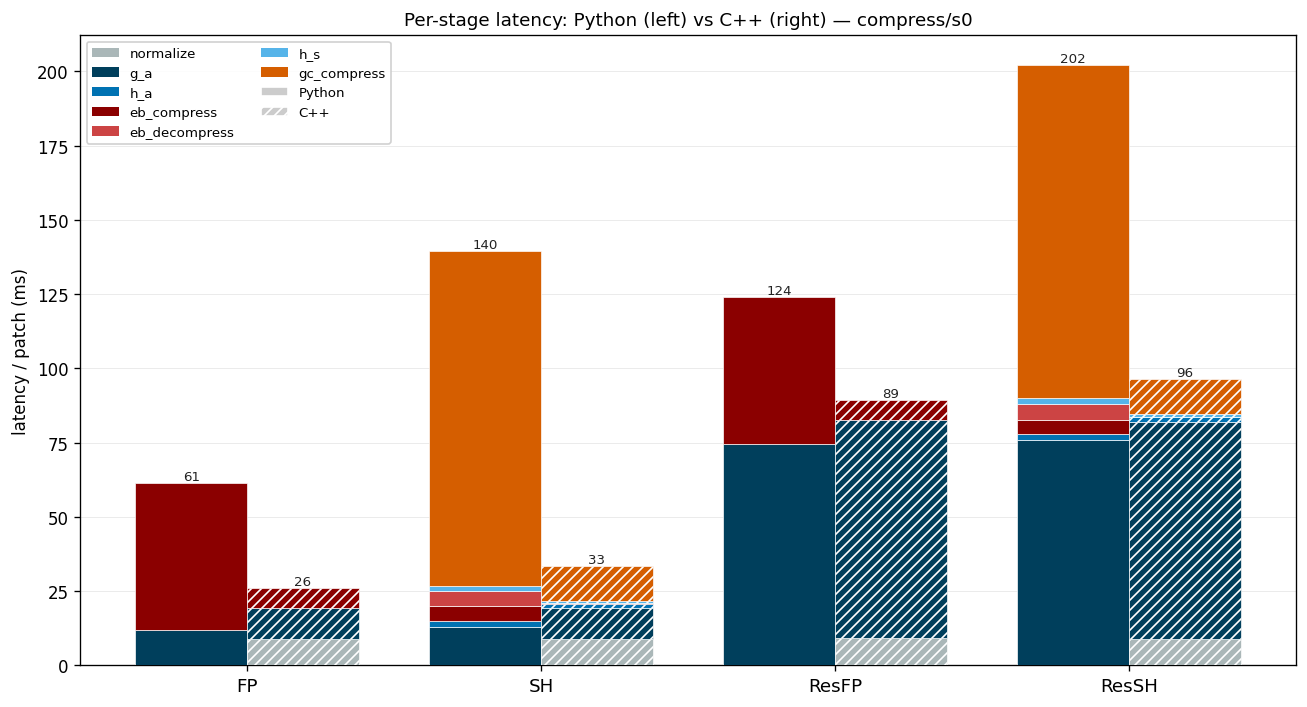

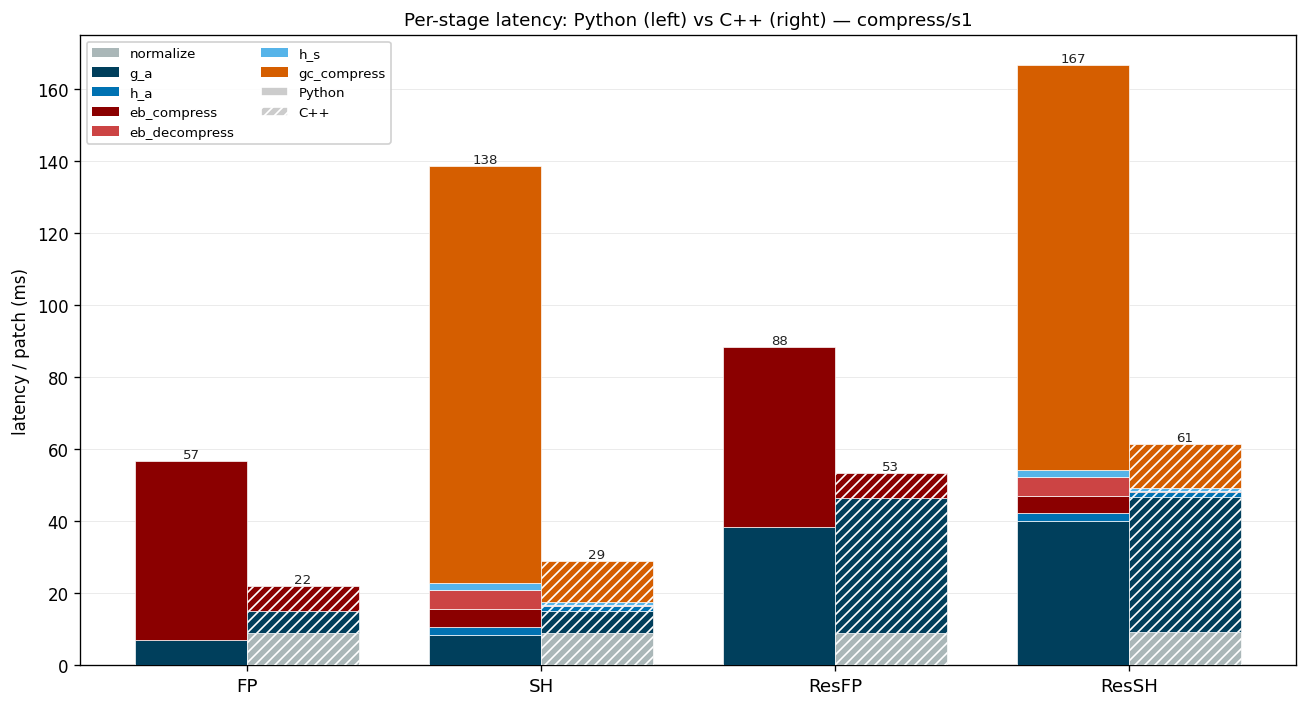

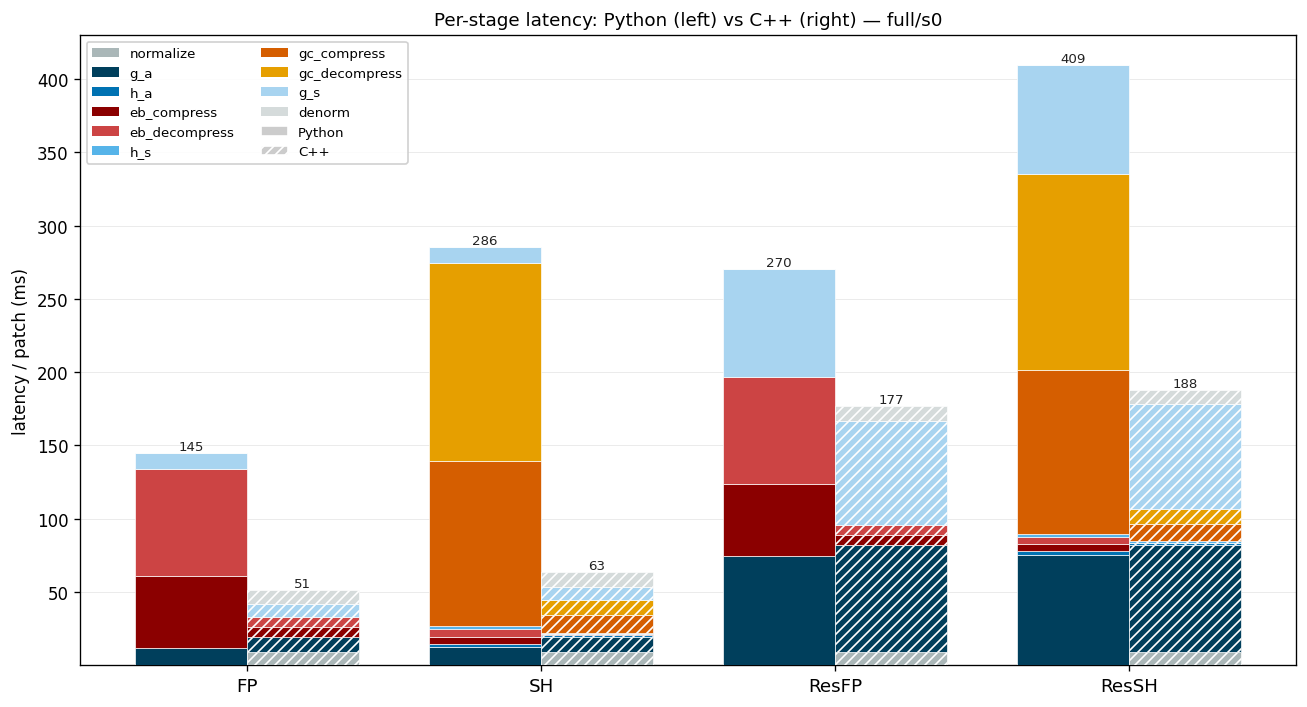

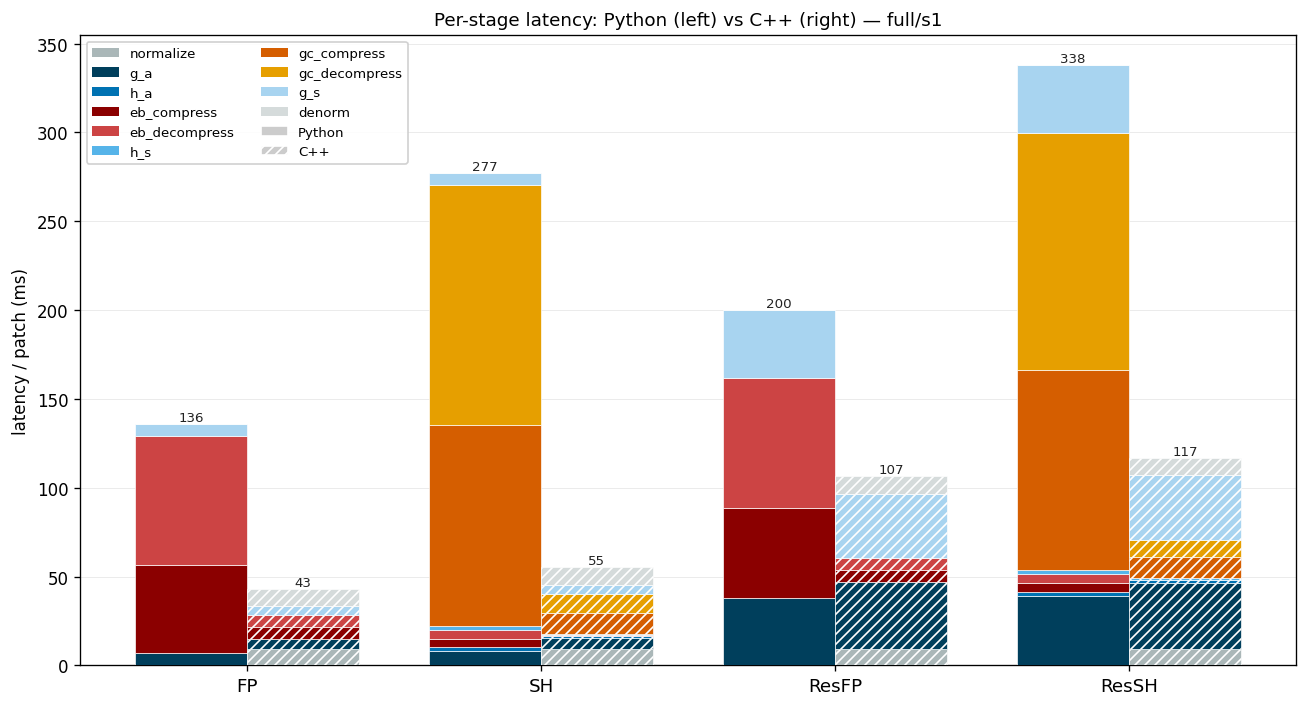

In [7]:
def plot_stage_breakdown(scenario="compress", config="s0"):
    """Stacked per-stage latency, Python (left) vs C++ (right). Bar total printed on top.
    scenario: 'compress'|'full', config: 's0'|'s1'."""
    sub = mig_df[(mig_df["scenario"] == scenario) & (mig_df["config"] == config)]
    archs = _archs_present(sub)
    x = np.arange(len(archs))
    w = 0.38

    fig, ax = plt.subplots(figsize=(11, 6), dpi=FIG_DPI)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.35, color="#aaa")
    present = set()
    for ai, arch in enumerate(archs):
        r = sub[sub["arch"] == arch].iloc[0]
        for backend, off, hatch in [("py", -0.5, ""), ("cpp", 0.5, "////")]:
            stages = r[f"{backend}_stage_ms"]
            bottom = 0.0
            for st in r["cpp_order"]:
                h = stages.get(st, 0.0)
                if h <= 0:
                    continue
                ax.bar(
                    x[ai] + off * w,
                    h,
                    width=w,
                    bottom=bottom,
                    color=STAGE_CLR.get(st, "#888"),
                    hatch=hatch,
                    edgecolor="white",
                    linewidth=0.4,
                    zorder=3,
                )
                present.add(st)
                bottom += h
            # bar total on top
            ax.text(
                x[ai] + off * w,
                bottom,
                f"{bottom:.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#222",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([ARCH_LABEL.get(a, a) for a in archs], fontsize=11)
    ax.set_ylabel("latency / patch (ms)")
    ax.set_title(
        f"Per-stage latency: Python (left) vs C++ (right) — {scenario}/{config}", fontsize=11
    )
    stage_h = [
        Patch(facecolor=STAGE_CLR.get(s, "#888"), label=s)
        for s in STAGE_LEGEND_ORDER
        if s in present
    ]
    style_h = [
        Patch(facecolor="#ccc", edgecolor="white", label="Python"),
        Patch(facecolor="#ccc", hatch="////", edgecolor="white", label="C++"),
    ]
    ax.legend(handles=stage_h + style_h, fontsize=8, loc="upper left", ncol=2, framealpha=0.9)
    fig.tight_layout()
    savefig(f"migration_stages_{scenario}_{config}")
    plt.show()


for _sc in ("compress", "full"):
    for _cf in ("s0", "s1"):
        plot_stage_breakdown(_sc, _cf)

In [ ]:
# Entropy-coding speedup (full / s0) — the heart of the migration win (C++ rANS vs Python).
# EB = EntropyBottleneck (hyperprior z, or y for FP); GC = GaussianConditional (y, SHyp only).
_ENTROPY = ["eb_compress", "eb_decompress", "gc_compress", "gc_decompress"]
print("Entropy-coding speedup — Python vs C++  (full scenario, s0)\n")
for arch in ARCH_ORDER:
    sub = mig_df[
        (mig_df["arch"] == arch) & (mig_df["scenario"] == "full") & (mig_df["config"] == "s0")
    ]
    if sub.empty:
        continue
    r = sub.iloc[0]
    print(f"{ARCH_LABEL.get(arch, arch)}:")
    for st in _ENTROPY:
        p = r["py_stage_ms"].get(st, 0.0)
        c = r["cpp_stage_ms"].get(st, 0.0)
        if p <= 0 or c <= 0:  # stage absent (e.g. GC for FP family)
            continue
        print(f"  {st:14s}  python: {p:8.3f} ms,  C++: {c:7.3f} ms  =>  {p / c:.1f}x")
    print()

Entropy-coding speedup — Python vs C++  (full scenario, s0)

FP:
  eb_compress     python:   49.291 ms,  C++:   6.772 ms  =>  7.3x
  eb_decompress   python:   72.701 ms,  C++:   6.785 ms  =>  10.7x

SH:
  eb_compress     python:    4.822 ms,  C++:   0.121 ms  =>  39.8x
  eb_decompress   python:    5.071 ms,  C++:   0.115 ms  =>  44.2x
  gc_compress     python:  112.629 ms,  C++:  11.990 ms  =>  9.4x
  gc_decompress   python:  134.997 ms,  C++:  10.386 ms  =>  13.0x

ResFP:
  eb_compress     python:   49.235 ms,  C++:   6.661 ms  =>  7.4x
  eb_decompress   python:   72.816 ms,  C++:   6.726 ms  =>  10.8x

ResSH:
  eb_compress     python:    4.915 ms,  C++:   0.115 ms  =>  42.6x
  eb_decompress   python:    5.176 ms,  C++:   0.112 ms  =>  46.1x
  gc_compress     python:  111.679 ms,  C++:  11.964 ms  =>  9.3x
  gc_decompress   python:  133.868 ms,  C++:   9.899 ms  =>  13.5x



## §3 Energy per patch

Simple energy proxy: MPSoC active power × total latency. C++ wins on both factors (lower power and
lower latency), so energy/patch drops sharply. (Same `scenario`/`config` switches.)

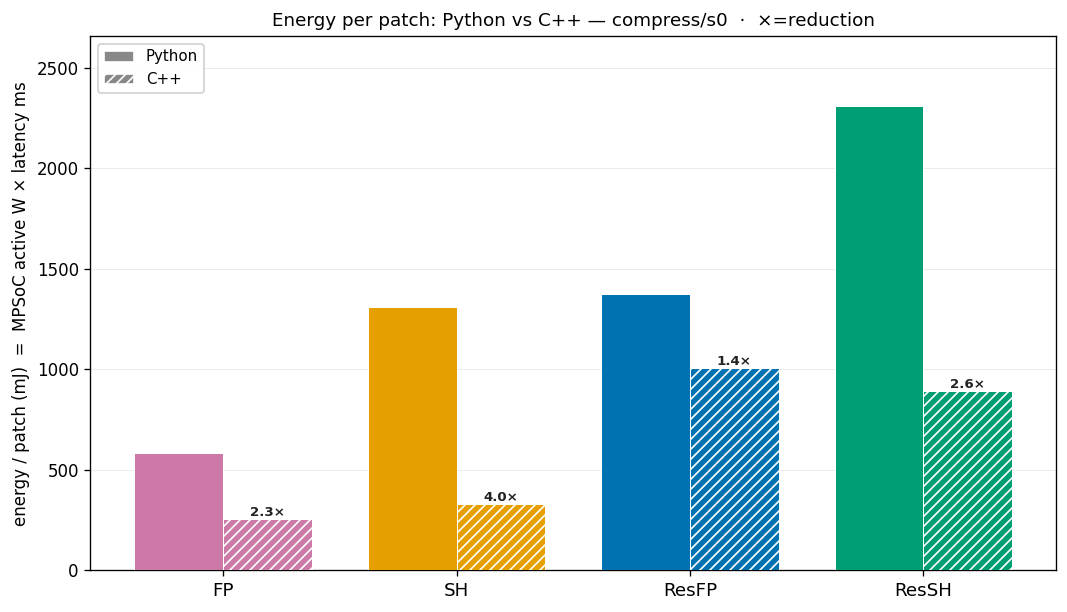

In [9]:
def plot_energy(scenario="compress", config="s0"):
    """Energy/patch (MPSoC active W × latency ms), Python vs C++; reduction factor above C++ bar."""
    sub = mig_df[(mig_df["scenario"] == scenario) & (mig_df["config"] == config)]
    archs = _archs_present(sub)
    x = np.arange(len(archs))
    w = 0.38

    fig, ax = plt.subplots(figsize=(9, 5.2), dpi=FIG_DPI)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.35, color="#aaa")
    ymax = 0
    for ai, arch in enumerate(archs):
        r = sub[sub["arch"] == arch].iloc[0]
        clr = ARCH_CLR.get(arch, "#888")
        pyv, cppv = r["py_energy_mj"], r["cpp_energy_mj"]
        if pd.isna(pyv) or pd.isna(cppv):
            continue
        ymax = max(ymax, pyv, cppv)
        ax.bar(x[ai] - w / 2, pyv, width=w, color=clr, edgecolor="white", linewidth=0.6, zorder=3)
        ax.bar(
            x[ai] + w / 2,
            cppv,
            width=w,
            color=clr,
            hatch="////",
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )
        ax.text(
            x[ai] + w / 2,
            cppv,
            f"{pyv / cppv:.1f}×",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#222",
        )
    ax.set_xticks(x)
    ax.set_xticklabels([ARCH_LABEL.get(a, a) for a in archs], fontsize=11)
    ax.set_ylabel("energy / patch (mJ)  =  MPSoC active W × latency ms")
    ax.set_ylim(0, ymax * 1.15)
    ax.set_title(
        f"Energy per patch: Python vs C++ — {scenario}/{config}  ·  ×=reduction", fontsize=11
    )
    leg = [
        Patch(facecolor="#888", edgecolor="white", label="Python"),
        Patch(facecolor="#888", hatch="////", edgecolor="white", label="C++"),
    ]
    ax.legend(handles=leg, fontsize=9, loc="upper left", framealpha=0.9)
    fig.tight_layout()
    savefig(f"migration_energy_{scenario}_{config}")
    plt.show()


plot_energy("compress", "s0")

## Takeaways

- C++ is faster everywhere: ~2.3× (FP compress) up to ~4× (SH compress) on total latency; the win is
  larger for the small models because their pipeline is **entropy-dominated** in Python.
- The migration win lives in **entropy coding** (C++ rANS): `gc_*`/`eb_*` stages collapse from tens/
  hundreds of ms to a few ms. DPU stages (`g_a`/`g_s`) are the same silicon → unchanged.
- Residual models (ResFP/ResSH) are **DPU-dominated**, so their relative speedup is smaller — the big
  `g_a`/`g_s` blocks don't move.
- S1 (channel parallelism) helps both backends, but Python's gain is muted (GIL/thread overhead);
  SH in Python barely improves S0→S1.
- Energy/patch drops ~2–3× (lower power AND lower latency).